<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
start = 0
end = 1
step = 0.01
X = torch.arange(start, end, step)

In [4]:
weight = 0.6
bias = -0.3
y = weight * X + bias

In [5]:
perm = torch.randperm(len(X))
X = X[perm]
y = y[perm]

In [6]:
train_split = int(0.8*len(X))
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

In [7]:
def plot_dataset(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=None):
  plt.figure(figsize=(5,4))
  plt.scatter(X_train, y_train, s=4, c='r', label="Training Data")
  plt.scatter(X_test, y_test, s=4, c="g", label="Testing Data")
  if predictions is not None:
    plt.scatter(X_test, predictions, s=4, c="b", label="Predictions")

  plt.legend(prop={"size": 14})

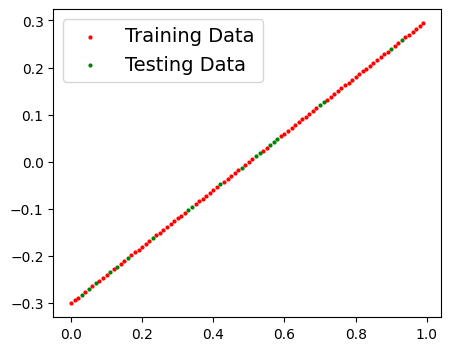

In [8]:
plot_dataset()

In [52]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32), requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32)) # requires_grad = True is default behavior

  def forward(self, X):
    return self.weights * X + self.bias

In [53]:
torch.manual_seed(13)

model = LinearRegressionModel()

tensor([-1.1925, -1.2104, -1.1534, -1.1836, -1.2495, -1.1713, -1.1601, -1.1490,
        -1.2081, -1.2249, -1.1825, -1.2238, -1.1992, -1.1512, -1.1579, -1.2048,
        -1.2037, -1.2461, -1.1635, -1.2093])


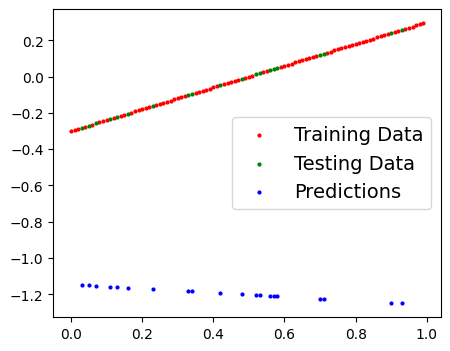

In [54]:
with torch.inference_mode():
  y_pred = model(X_test)
  print(y_pred)
plot_dataset(predictions=y_pred)

In [55]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [56]:
epochs = 1000

epoch_count = []
train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
  model.train()
  y_pred = model(X_train)
  loss = loss_fn(y_train, y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    y_test_pred = model(X_test)
    test_loss = loss_fn(y_test, y_test_pred)

  if epochs%10 == 0:
    epoch_count.append(epoch)
    train_loss_history.append(loss.detach().numpy())
    test_loss_history.append(test_loss.detach().numpy())
    # print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

In [40]:
print(train_loss_history)
print(test_loss_history)

[array(1.5107247, dtype=float32), array(1.4730674, dtype=float32), array(1.4358982, dtype=float32), array(1.3992258, dtype=float32), array(1.3630576, dtype=float32), array(1.3274014, dtype=float32), array(1.2922643, dtype=float32), array(1.257653, dtype=float32), array(1.2235732, dtype=float32), array(1.1900316, dtype=float32), array(1.157033, dtype=float32), array(1.1245823, dtype=float32), array(1.0926841, dtype=float32), array(1.0613422, dtype=float32), array(1.0305598, dtype=float32), array(1.0003399, dtype=float32), array(0.9706849, dtype=float32), array(0.9415966, dtype=float32), array(0.9130764, dtype=float32), array(0.8851248, dtype=float32), array(0.8577423, dtype=float32), array(0.8309286, dtype=float32), array(0.8046831, dtype=float32), array(0.77900445, dtype=float32), array(0.753891, dtype=float32), array(0.7293407, dtype=float32), array(0.70535076, dtype=float32), array(0.6819183, dtype=float32), array(0.65903986, dtype=float32), array(0.63671166, dtype=float32), array(0.

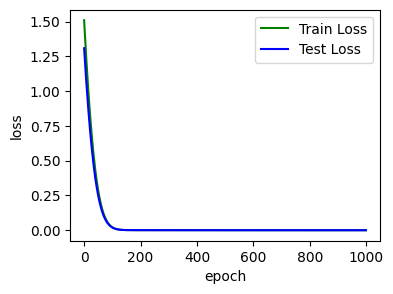

In [57]:
plt.figure(figsize=(4,3))
plt.plot(epoch_count, train_loss_history, c="g",label="Train Loss")
plt.plot(epoch_count, test_loss_history, c="b",label="Test Loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

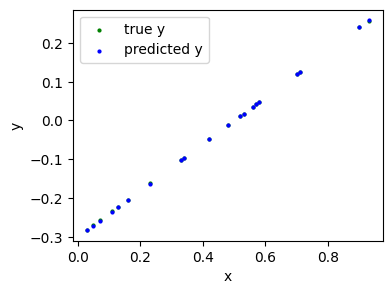

In [58]:
y_test_pred = model(X_test)
plt.figure(figsize=(4,3))
plt.scatter(X_test, y_test, c='g', s=4, label="true y")
plt.scatter(X_test, y_test_pred.detach().numpy(), c='b', s=4, label="predicted y")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [59]:
model.state_dict()

OrderedDict([('weights', tensor([0.6021])), ('bias', tensor([-0.3012]))])